# Regression Algorithms


**Dataset:** California Housing Dataset (scikit-learn)

**Algorithms covered:**
1. Simple Linear Regression
2. Multiple Linear Regression
3. Polynomial Regression
4. Ridge Regression
5. Lasso Regression
6. Elastic Net Regression
7. Decision Tree Regression
8. Random Forest Regression
9. Support Vector Regression (SVR)
10. Gradient Boosting Regression

**Evaluation metrics:** MAE, MSE, RMSE and R² Score

>

In [1]:
# 1. Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Load the dataset

The California Housing dataset contains information about housing districts in California.

**Target:** Median House Value

The features include median income, house age, average rooms, population, latitude, longitude, etc.

In [2]:
# Load dataset
housing = fetch_california_housing(as_frame=True)

df = housing.frame.copy()

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (20640, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [ ]:
# Dataset information
df.info()

print("\nMissing values:")
print(df.isnull().sum())

print("\nStatistical summary:")
display(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB

Missing values:
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

Statistical summary:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


## 3. Exploratory Data Analysis (EDA)

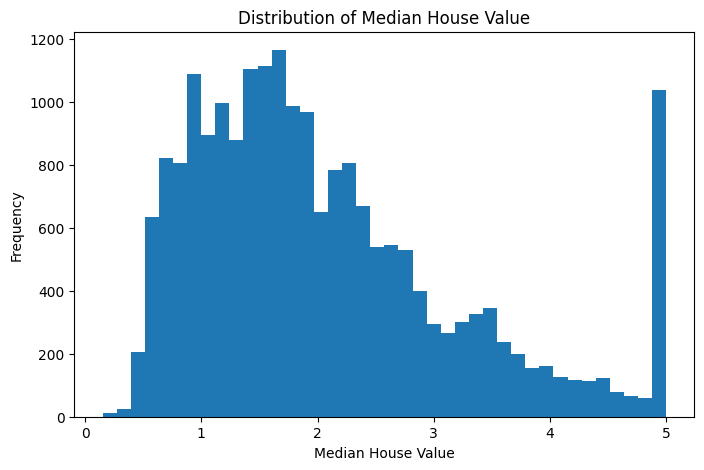

In [ ]:
# Distribution of target variable
plt.figure(figsize=(8, 5))
plt.hist(df["MedHouseVal"], bins=40)
plt.xlabel("Median House Value")
plt.ylabel("Frequency")
plt.title("Distribution of Median House Value")
plt.show()

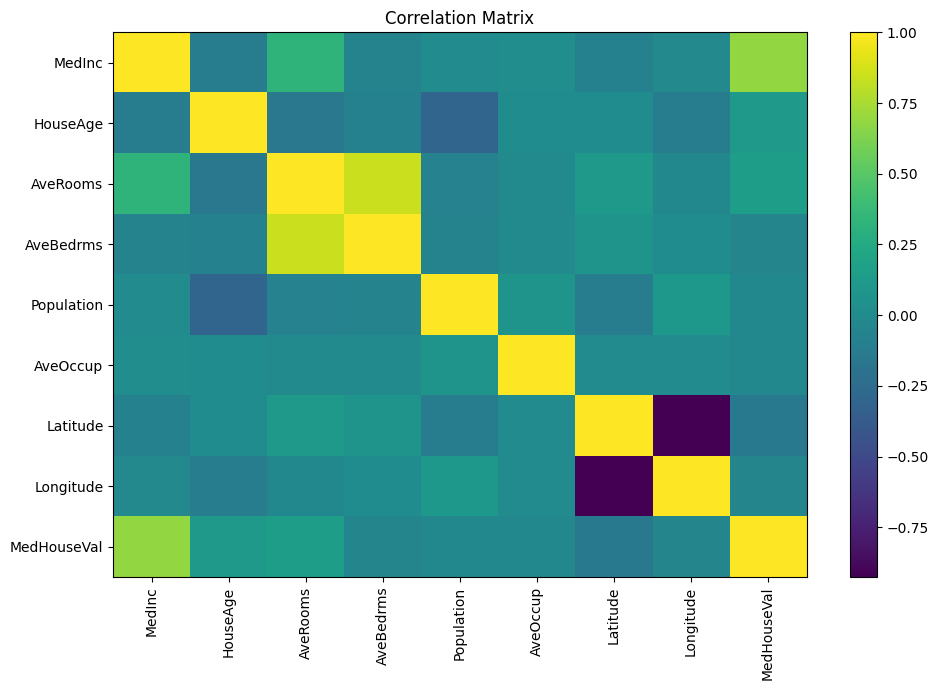

In [ ]:
# Correlation matrix
plt.figure(figsize=(10, 7))
plt.imshow(df.corr(), aspect="auto")
plt.colorbar()
plt.xticks(range(len(df.columns)), df.columns, rotation=90)
plt.yticks(range(len(df.columns)), df.columns)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

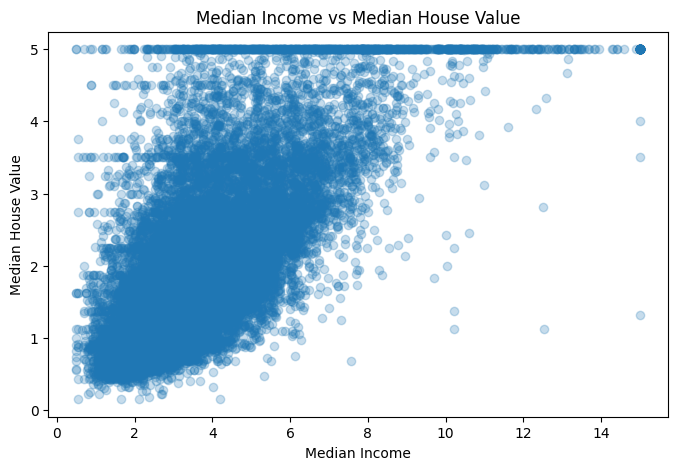

In [ ]:
# Relationship between median income and house value
plt.figure(figsize=(8, 5))
plt.scatter(df["MedInc"], df["MedHouseVal"], alpha=0.25)
plt.xlabel("Median Income")
plt.ylabel("Median House Value")
plt.title("Median Income vs Median House Value")
plt.show()

## 4. Prepare the data

`X` contains the independent variables and `y` contains the target variable.

We use an 80:20 train-test split.

In [ ]:
X = df.drop("MedHouseVal", axis=1)
y = df["MedHouseVal"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 16512
Testing samples: 4128


In [ ]:
# Evaluation function
results = []

def evaluate_model(name, model, Xtr=X_train, Xte=X_test):
    model.fit(Xtr, y_train)
    pred = model.predict(Xte)

    mae = mean_absolute_error(y_test, pred)
    mse = mean_squared_error(y_test, pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, pred)

    results.append({
        "Model": name,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R² Score": r2
    })

    print(f"{name}")
    print(f"MAE  : {mae:.4f}")
    print(f"MSE  : {mse:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"R²   : {r2:.4f}")
    return model, pred

## 5. Simple Linear Regression

For simple linear regression, we use only one feature: **MedInc** (median income).

In [ ]:
X_simple = df[["MedInc"]]

Xtr_s, Xte_s, ytr_s, yte_s = train_test_split(
    X_simple, y, test_size=0.20, random_state=42
)

simple_lr = LinearRegression()
simple_lr.fit(Xtr_s, ytr_s)

pred_simple = simple_lr.predict(Xte_s)

print("Simple Linear Regression")
print("Slope:", simple_lr.coef_[0])
print("Intercept:", simple_lr.intercept_)
print("R² Score:", r2_score(yte_s, pred_simple))

Simple Linear Regression
Slope: 0.4193384939381271
Intercept: 0.4445972916907879
R² Score: 0.45885918903846656


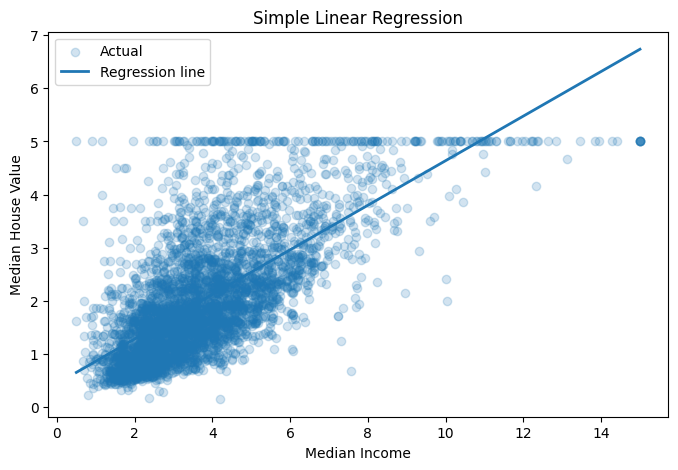

In [ ]:
# Graph: actual observations and fitted regression line
order = np.argsort(Xte_s["MedInc"].values)

plt.figure(figsize=(8, 5))
plt.scatter(Xte_s["MedInc"], yte_s, alpha=0.2, label="Actual")
plt.plot(
    Xte_s["MedInc"].values[order],
    pred_simple[order],
    linewidth=2,
    label="Regression line"
)
plt.xlabel("Median Income")
plt.ylabel("Median House Value")
plt.title("Simple Linear Regression")
plt.legend()
plt.show()

## 6. Multiple Linear Regression

Multiple linear regression uses all available features to predict the target.

In [ ]:
multiple_lr, pred_lr = evaluate_model(
    "Multiple Linear Regression",
    LinearRegression()
)

Multiple Linear Regression
MAE  : 0.5332
MSE  : 0.5559
RMSE : 0.7456
R²   : 0.5758


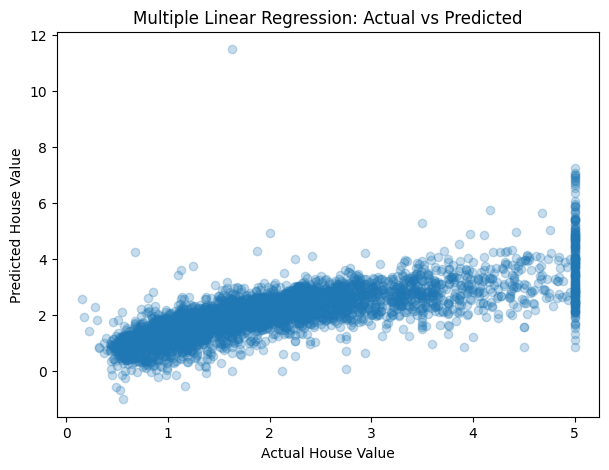

In [ ]:
# Actual vs predicted graph
plt.figure(figsize=(7, 5))
plt.scatter(y_test, pred_lr, alpha=0.25)
plt.xlabel("Actual House Value")
plt.ylabel("Predicted House Value")
plt.title("Multiple Linear Regression: Actual vs Predicted")
plt.show()

## 7. Polynomial Regression

Polynomial regression adds powers and interactions of the input features. To keep computation practical, this demonstration uses the `MedInc` feature with degree 2.

In [ ]:
poly_model = Pipeline([
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("linear", LinearRegression())
])

Xtr_p, Xte_p, ytr_p, yte_p = train_test_split(
    df[["MedInc"]], y, test_size=0.20, random_state=42
)

poly_model.fit(Xtr_p, ytr_p)
pred_poly = poly_model.predict(Xte_p)

print("Polynomial Regression")
print("MAE :", mean_absolute_error(yte_p, pred_poly))
print("MSE :", mean_squared_error(yte_p, pred_poly))
print("RMSE:", np.sqrt(mean_squared_error(yte_p, pred_poly)))
print("R²  :", r2_score(yte_p, pred_poly))

Polynomial Regression
MAE : 0.6282915588701903
MSE : 0.7032732680932144
RMSE: 0.8386138969115731
R²  : 0.46331772769346224


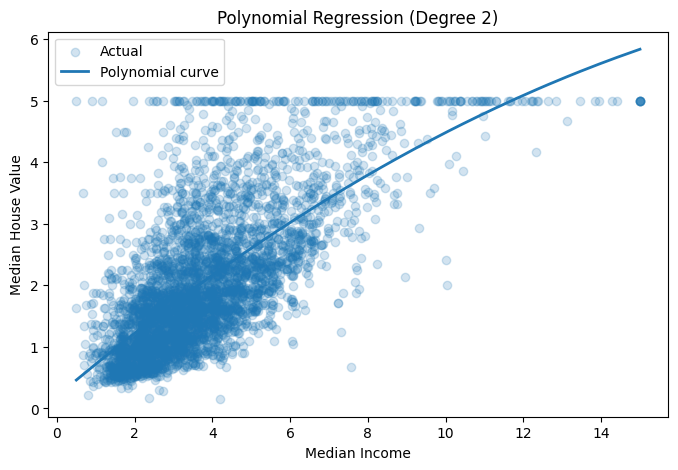

In [ ]:
# Polynomial regression graph
order = np.argsort(Xte_p["MedInc"].values)

plt.figure(figsize=(8, 5))
plt.scatter(Xte_p["MedInc"], yte_p, alpha=0.2, label="Actual")
plt.plot(
    Xte_p["MedInc"].values[order],
    pred_poly[order],
    linewidth=2,
    label="Polynomial curve"
)
plt.xlabel("Median Income")
plt.ylabel("Median House Value")
plt.title("Polynomial Regression (Degree 2)")
plt.legend()
plt.show()

## 8. Ridge Regression

Ridge regression uses **L2 regularization** to reduce overfitting and handle correlated features.

In [ ]:
ridge_model = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=1.0))
])

ridge_model, pred_ridge = evaluate_model("Ridge Regression", ridge_model)

Ridge Regression
MAE  : 0.5332
MSE  : 0.5559
RMSE : 0.7456
R²   : 0.5758


## 9. Lasso Regression

Lasso uses **L1 regularization**, which can shrink some coefficients toward zero.

In [ ]:
lasso_model = Pipeline([
    ("scaler", StandardScaler()),
    ("lasso", Lasso(alpha=0.001, max_iter=10000))
])

lasso_model, pred_lasso = evaluate_model("Lasso Regression", lasso_model)

Lasso Regression
MAE  : 0.5331
MSE  : 0.5545
RMSE : 0.7446
R²   : 0.5769


## 10. Elastic Net Regression

Elastic Net combines L1 and L2 regularization.

In [ ]:
elastic_model = Pipeline([
    ("scaler", StandardScaler()),
    ("elastic", ElasticNet(alpha=0.001, l1_ratio=0.5, max_iter=10000))
])

elastic_model, pred_elastic = evaluate_model("Elastic Net Regression", elastic_model)

Elastic Net Regression
MAE  : 0.5331
MSE  : 0.5549
RMSE : 0.7449
R²   : 0.5765


## 11. Decision Tree Regression

A decision tree recursively splits the data into regions and predicts a value in each region.

In [ ]:
tree_model = DecisionTreeRegressor(
    max_depth=10,
    random_state=42
)

tree_model, pred_tree = evaluate_model(
    "Decision Tree Regression",
    tree_model
)

Decision Tree Regression
MAE  : 0.4332
MSE  : 0.4155
RMSE : 0.6446
R²   : 0.6829


## 12. Random Forest Regression

Random Forest combines predictions from many decision trees to improve generalization.

In [ ]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

rf_model, pred_rf = evaluate_model(
    "Random Forest Regression",
    rf_model
)

Random Forest Regression
MAE  : 0.3332
MSE  : 0.2616
RMSE : 0.5115
R²   : 0.8004


## 13. Support Vector Regression (SVR)

SVR is sensitive to feature scale, so StandardScaler is included in the pipeline.

In [ ]:
svr_model = Pipeline([
    ("scaler", StandardScaler()),
    ("svr", SVR(kernel="rbf", C=100, epsilon=0.1))
])

svr_model, pred_svr = evaluate_model(
    "Support Vector Regression",
    svr_model
)

Support Vector Regression
MAE  : 0.3717
MSE  : 0.3201
RMSE : 0.5658
R²   : 0.7557


## 14. Gradient Boosting Regression

Gradient Boosting builds trees sequentially, with later trees attempting to correct errors made by earlier trees.

In [ ]:
gb_model = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gb_model, pred_gb = evaluate_model(
    "Gradient Boosting Regression",
    gb_model
)

Gradient Boosting Regression
MAE  : 0.4054
MSE  : 0.3370
RMSE : 0.5805
R²   : 0.7428


## 15. Compare all models

**Lower MAE/MSE/RMSE is better. Higher R² is better.**

In [ ]:
comparison = pd.DataFrame(results)
comparison = comparison.sort_values("R² Score", ascending=False).reset_index(drop=True)

display(comparison.round(4))

,Model,MAE,MSE,RMSE,R² Score
0,Random Forest Regression,0.3332,0.2616,0.5115,0.8004
1,Support Vector Regression,0.3717,0.3201,0.5658,0.7557
2,Gradient Boosting Regression,0.4054,0.3370,0.5805,0.7428
3,Decision Tree Regression,0.4332,0.4155,0.6446,0.6829
4,Lasso Regression,0.5331,0.5545,0.7446,0.5769
5,Elastic Net Regression,0.5331,0.5549,0.7449,0.5765
6,Ridge Regression,0.5332,0.5559,0.7456,0.5758
7,Multiple Linear Regression,0.5332,0.5559,0.7456,0.5758


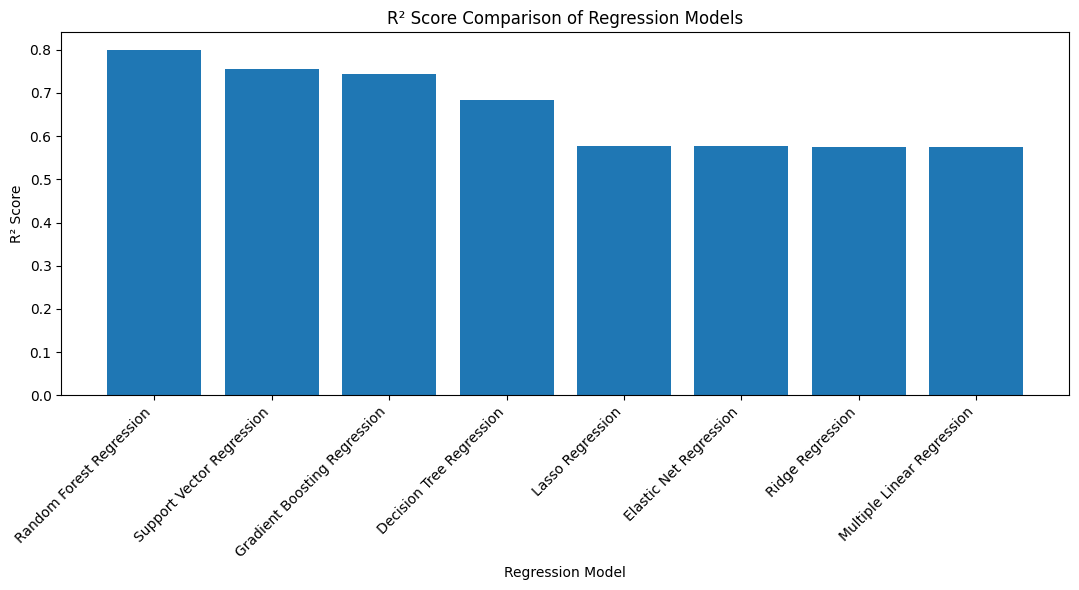

In [ ]:
# R² comparison graph
plt.figure(figsize=(11, 6))
plt.bar(comparison["Model"], comparison["R² Score"])
plt.ylabel("R² Score")
plt.xlabel("Regression Model")
plt.title("R² Score Comparison of Regression Models")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

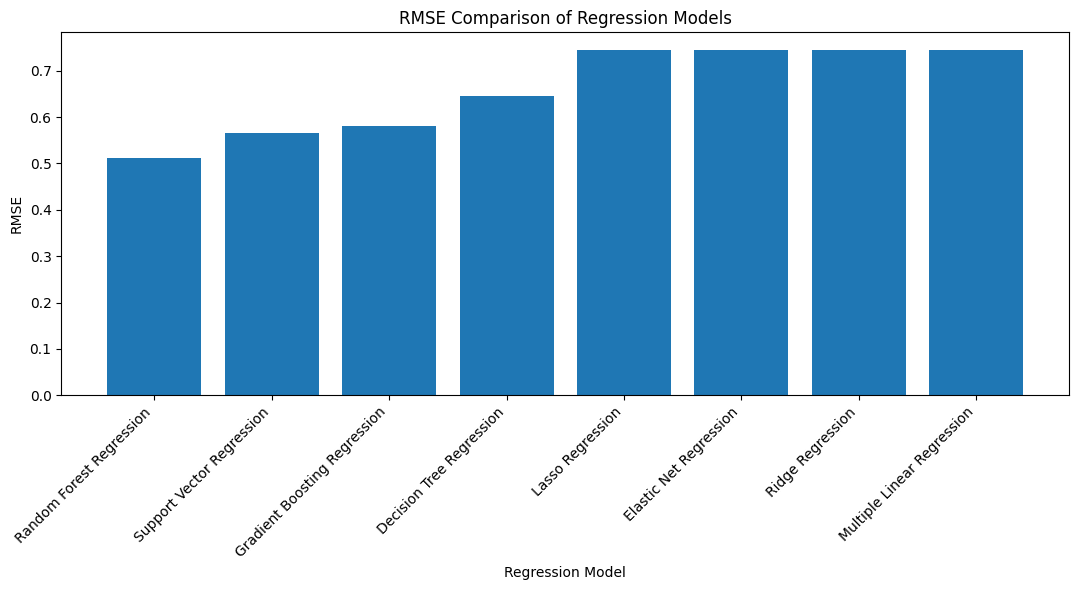

In [ ]:
# RMSE comparison graph
plt.figure(figsize=(11, 6))
plt.bar(comparison["Model"], comparison["RMSE"])
plt.ylabel("RMSE")
plt.xlabel("Regression Model")
plt.title("RMSE Comparison of Regression Models")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 16. Actual vs Predicted – Best Model

We select the model with the highest R² score and visualize its predictions.

Best model based on R²: Random Forest Regression


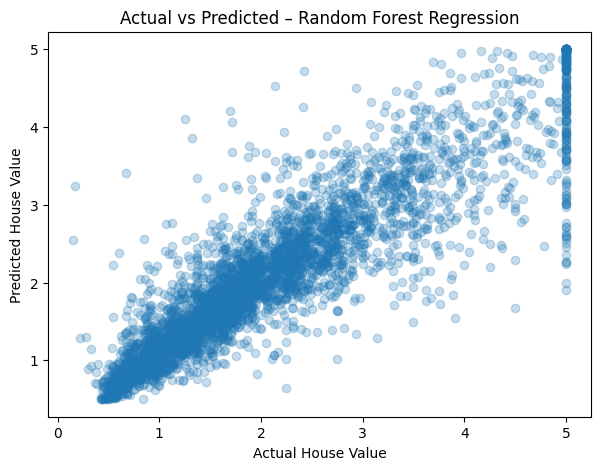

In [ ]:
best_model_name = comparison.iloc[0]["Model"]
print("Best model based on R²:", best_model_name)

prediction_map = {
    "Multiple Linear Regression": pred_lr,
    "Ridge Regression": pred_ridge,
    "Lasso Regression": pred_lasso,
    "Elastic Net Regression": pred_elastic,
    "Decision Tree Regression": pred_tree,
    "Random Forest Regression": pred_rf,
    "Support Vector Regression": pred_svr,
    "Gradient Boosting Regression": pred_gb
}

best_predictions = prediction_map.get(best_model_name)

if best_predictions is not None:
    plt.figure(figsize=(7, 5))
    plt.scatter(y_test, best_predictions, alpha=0.25)
    plt.xlabel("Actual House Value")
    plt.ylabel("Predicted House Value")
    plt.title(f"Actual vs Predicted – {best_model_name}")
    plt.show()
else:
    print("The best model is Simple/Polynomial Regression, which used a separate one-feature split.")

## 17. Conclusion

In this project, I have implemented  multiple regression algorithms on the California Housing dataset.

The models were evaluated using **MAE, MSE, RMSE and R² Score**. The best model is selected based on the highest R² score, while lower error values indicate better predictive performance.Simple Linear Regression and Polynomial Regression are not added to the common results list.

The comparison demonstrates that different regression algorithms can produce substantially different results on the same dataset. Tree-based ensemble methods such as Random Forest and Gradient Boosting can capture nonlinear relationships that ordinary linear models may not capture well.

